# Homework 2: Linear & Logistic Regression
 - By: Colson Keim | 811804097
 - Wed Feb 18 12:04PM
 - MIST 5635

## Citations
 - Google Gemini
 - VS Code
 - Copilot Intellisense

# Linear Regression

## Part A - Data Readiness

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

# from google.colab import files
# df = pd.read_csv("/content/Credit-Default.csv")
dfT = pd.read_csv("/Users/colekeim/Downloads/UGA/MIST 5635/Data_Files/Housing-Prices.csv", na_values=["", "NA", "NaN", "null", "None", " "])

In [2]:
dfT['ocean_proximity'] = dfT['ocean_proximity'].astype('category')
dfT['ocean_proximity'] = dfT['ocean_proximity'].cat.codes

In [ ]:
from sklearn.model_selection import train_test_split

# Data Splitting into Train, Val, and Test
df_train_val, df_test = train_test_split(dfT, test_size=0.15, random_state=25)
df_train, df_val = train_test_split(df_train_val, test_size=(15/85), random_state=25)

In [4]:
# Separate the features (X) from the target variable (y)
# Target variable is 'median_house_value'

# 1. Training Data
y_train = df_train['median_house_value']
X_train = df_train.drop('median_house_value', axis=1)

# 2. Validation Data
y_val = df_val['median_house_value']
X_val = df_val.drop('median_house_value', axis=1)

# 3. Test Data
y_test = df_test['median_house_value']
X_test = df_test.drop('median_house_value', axis=1)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Separating the 9 features
numeric_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                    'total_bedrooms', 'population', 'households', 'median_income']
# This is the categorical variable
categorical_features = ['ocean_proximity']

# Transformers
# Pipeline for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features
# (handle_unknown='ignore' ensures the model doesn't crash if it sees a new category in test data)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Create the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline >>> now we combine the preprocessor with the model
pipe_simple = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

## Part B - Analysis

### a. All Features

In [6]:
# Fit the regression model with the training data
pipe_simple.fit(X_train, y_train)

# Predict on train and val
y_hat_train_all = pipe_simple.predict(X_train)
y_hat_val_all = pipe_simple.predict(X_val)

aR2 = pipe_simple.score(X_val, y_val)
aRMSE = np.sqrt(mean_squared_error(y_val, y_hat_val_all))

# Check results
print("Training Score (R2):", pipe_simple.score(X_train, y_train))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_hat_train_all)))  

print("------------------------------------")


print("Validation Score (R2):", aR2)
print("Validation RMSE:", aRMSE)



Training Score (R2): 0.6418564699984548
Training RMSE: 69128.15394903425
------------------------------------
Validation Score (R2): 0.6681058238796989
Validation RMSE: 67476.68794981623


### b. All Features + two interesting ratios

In [7]:
# Feat + 2 IV's

# The Two IV's are:
for df_x in [X_train, X_val, X_test]:
    df_x['avg_rooms'] = df_x['total_rooms'] / df_x['households'] # avg rooms
    df_x['avg_bed'] = df_x['total_bedrooms'] / df_x['households'] # avg bedrooms

# Update the feature lists to include the new IVs
numeric_features_ratios = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                           'total_bedrooms', 'population', 'households', 'median_income',
                           'avg_rooms', 'avg_bed'] # adding the two new IVs to the list of numeric features

# Update the preprocessor to include the new IVs
preprocessor_ratios = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_ratios),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline with the new preprocessor
pipe_ratios = Pipeline(steps=[
    ('preprocessor', preprocessor_ratios),
    ('regressor', LinearRegression())
])

# Fit the regression model with the training data
pipe_ratios.fit(X_train, y_train)

y_hat_train_ratios = pipe_ratios.predict(X_train) # Predict on train
y_hat_val_ratios = pipe_ratios.predict(X_val) # Predict on val

# Val variable assigments
bR2 = pipe_ratios.score(X_val, y_val)
bRMSE = np.sqrt(mean_squared_error(y_val, y_hat_val_ratios))

# Check results
print("Training Score (R2) with Ratios:", pipe_ratios.score(X_train, y_train))
print("Training RMSE with Ratios:", np.sqrt(mean_squared_error(y_train, y_hat_train_ratios)))

print("------------------------------------")

print("Validation Score (R2) with Ratios:", bR2)
print("Validation RMSE with Ratios:", bRMSE)


Training Score (R2) with Ratios: 0.6455260898860888
Training RMSE with Ratios: 68773.09071577164
------------------------------------
Validation Score (R2) with Ratios: 0.6625989710510516
Validation RMSE with Ratios: 68034.17814294528


### c. All Features & polynomial combo

In [8]:
from sklearn.preprocessing import PolynomialFeatures

# Define the features to be transformed and the other numeric features
poly_features = ['latitude', 'longitude']  # Example features to be transformed & categorical variable stays the same
other_numeric_features = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

# Create polynomial feature transformer
poly_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create the new ColumnTransformer to include polynomial features
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('poly', poly_transformer, poly_features),
        ('num', numeric_transformer, other_numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline with polynomial features
pipe_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

# Fit the regression model with the training data
pipe_poly.fit(X_train, y_train)

y_hat_train_poly = pipe_poly.predict(X_train)
y_hat_val_poly = pipe_poly.predict(X_val)

# Val variable assigments
cR2 = pipe_poly.score(X_val, y_val)
cRMSE = np.sqrt(mean_squared_error(y_val, y_hat_val_poly))

# Check results
print("Training Score (R2) with Polynomial Features:", pipe_poly.score(X_train, y_train))
print("Training RMSE with Polynomial Features:", np.sqrt(mean_squared_error(y_train, y_hat_train_poly)))

print("------------------------------------")

print("Validation Score (R2) with Polynomial Features:", cR2)
print("Validation RMSE with Polynomial Features:", cRMSE)

Training Score (R2) with Polynomial Features: 0.6507588062654062
Training RMSE with Polynomial Features: 68263.5919127847
------------------------------------
Validation Score (R2) with Polynomial Features: 0.6757350360741142
Validation RMSE with Polynomial Features: 66696.63984522999


### d. Regularized Regression w/ all the vars

In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Set up the features for the complete model with polynomial features and ratios
other_numeric_features_complete = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'avg_rooms', 'avg_bed']  
# poly_features remain the same as before
# categorical_features remain the same as before

# Build the preprocessor for the complete model
preprocessor_complete = ColumnTransformer(
    transformers=[
        ('poly', poly_transformer, poly_features),
        ('num', numeric_transformer, other_numeric_features_complete),
        ('cat', categorical_transformer, categorical_features)
    ])

# Initialize variables before the loop (optional but good practice)
dR2_001, dRMSE_001 = 0, 0
dR2_1, dRMSE_1 = 0, 0
dR2_1000, dRMSE_1000 = 0, 0

alphas = [0.001, 1, 1000]

for a in alphas:
    pipe_ridge = Pipeline(steps=[
        ('preprocessor', preprocessor_complete),
        ('regressor', Ridge(alpha=a))
    ])

    pipe_ridge.fit(X_train, y_train)
    
    # Calculate metrics
    val_r2 = pipe_ridge.score(X_val, y_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, pipe_ridge.predict(X_val)))

    # Assign to specific variables based on alpha
    if a == 0.001:
        dR2_001, dRMSE_001 = val_r2, val_rmse
    elif a == 1:
        dR2_1, dRMSE_1 = val_r2, val_rmse
    elif a == 1000:
        dR2_1000, dRMSE_1000 = val_r2, val_rmse


# Check results for alphas
print("Validation Score (R2) with Ridge (alpha=0.001):", dR2_001)
print("Validation RMSE with Ridge       (alpha=0.001):", dRMSE_001)       
print("------------------------------------")
print("Validation Score (R2) with Ridge (alpha=1):", dR2_1)
print("Validation RMSE with Ridge       (alpha=1):", dRMSE_1)       
print("------------------------------------")
print("Validation Score (R2) with Ridge (alpha=1000):", dR2_1000)
print("Validation RMSE with Ridge       (alpha=1000):", dRMSE_1000)

Validation Score (R2) with Ridge (alpha=0.001): 0.6711514258929955
Validation RMSE with Ridge       (alpha=0.001): 67166.37704001385
------------------------------------
Validation Score (R2) with Ridge (alpha=1): 0.664090682357733
Validation RMSE with Ridge       (alpha=1): 67883.6158058048
------------------------------------
Validation Score (R2) with Ridge (alpha=1000): 0.6574562428073052
Validation RMSE with Ridge       (alpha=1000): 68550.71200897548


## Results



### Full Model-By-Model Comparison

In [10]:
# Compare the results of all 4 models (Simple, Ratios, Polynomial, Complete) on the validation set
print("Model Comparison on Validation Set:")
print("--- FINAL MODEL COMPARISON ---")
print(f"Model A (Base):        RMSE = {aRMSE:,.2f}, R2 = {aR2:.4f}")
print(f"Model B (Ratios):      RMSE = {bRMSE:,.2f}, R2 = {bR2:.4f}")
print(f"Model C (Poly):        RMSE = {cRMSE:,.2f}, R2 = {cR2:.4f}")
print(f"Model D (Ridge 0.001): RMSE = {dRMSE_001:,.2f}, R2 = {dR2_001:.4f}")
print(f"Model D (Ridge 1):     RMSE = {dRMSE_1:,.2f}, R2 = {dR2_1:.4f}")
print(f"Model D (Ridge 1000):  RMSE = {dRMSE_1000:,.2f}, R2 = {dR2_1000:.4f}")

Model Comparison on Validation Set:
--- FINAL MODEL COMPARISON ---
Model A (Base):        RMSE = 67,476.69, R2 = 0.6681
Model B (Ratios):      RMSE = 68,034.18, R2 = 0.6626
Model C (Poly):        RMSE = 66,696.64, R2 = 0.6757
Model D (Ridge 0.001): RMSE = 67,166.38, R2 = 0.6712
Model D (Ridge 1):     RMSE = 67,883.62, R2 = 0.6641
Model D (Ridge 1000):  RMSE = 68,550.71, R2 = 0.6575


### Best Model

In [11]:
# Based on the val-set results; best model
# 1. Create a list of all your models
# format: (Name, Pipeline_Object)
model_list = [
    ("Model A: All Features", pipe_simple),
    ("Model B: Features + Ratios", pipe_ratios),
    ("Model C: Poly Lat/Lon", pipe_poly)
]

# 2. Add the Ridge models to the list (using a quick loop for the alphas)
for a in [0.001, 1, 1000]:
    # We rebuild the ridge pipeline for each alpha here to add it to the list
    p = Pipeline(steps=[
        ('preprocessor', preprocessor_complete),
        ('regressor', Ridge(alpha=a))
    ])
    model_list.append((f"Model D: Ridge (alpha={a})", p))

# 3. Create placeholders to track the "Best" model
best_rmse = float('inf') # Start with infinity so any model is better
best_model_name = ""
results = []

# 4. The Comparison Loop
print(f"{'Model Name':<30} | {'Val R2':<10} | {'Val RMSE':<10}")
print("-" * 55)

for name, model in model_list:
    # Fit
    model.fit(X_train, y_train)
    
    # Predict & Score
    val_preds = model.predict(X_val)
    val_r2 = model.score(X_val, y_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    # Print row
    print(f"{name:<30} | {val_r2:<10.4f} | {val_rmse:<10.2f}")
    
    # Store for final decision
    results.append({"name": name, "rmse": val_rmse, "r2": val_r2})
    
    # Logic to "choose" the best
    if val_rmse < best_rmse:
        best_rmse = val_rmse
        best_model_name = name

print("-" * 55)
print(f"WINNER: {best_model_name} with RMSE of {best_rmse:,.2f}")

Model Name                     | Val R2     | Val RMSE  
-------------------------------------------------------
Model A: All Features          | 0.6681     | 67476.69  
Model B: Features + Ratios     | 0.6626     | 68034.18  
Model C: Poly Lat/Lon          | 0.6757     | 66696.64  
Model D: Ridge (alpha=0.001)   | 0.6712     | 67166.38  
Model D: Ridge (alpha=1)       | 0.6641     | 67883.62  
Model D: Ridge (alpha=1000)    | 0.6575     | 68550.71  
-------------------------------------------------------
WINNER: Model C: Poly Lat/Lon with RMSE of 66,696.64


### Using the TEST SET with the best model

In [ ]:
# 1. Initialize variables to track the winning model
best_rmse = float('inf')
best_model_name = ""
best_model_obj = None  # This will store the actual winning pipeline

# 2. The Comparison Loop (similar to before)
for name, model in model_list:
    # We don't need to .fit() again if they are already fitted, 
    # but it doesn't hurt if you want to be sure.
    model.fit(X_train, y_train)
    
    val_preds = model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    if val_rmse < best_rmse:
        best_rmse = val_rmse
        best_model_name = name
        best_model_obj = model # Save the actual pipeline here!

# FINAL TEST SET EVALUATION
print(f"--- FINAL EVALUATION ON TEST SET ---")
print(f"The winning model is: {best_model_name}")

# Use the 'best_model_obj' variable to predict on Test data
# This works regardless of whether the winner was A, B, C, or Ridge
y_test_hat = best_model_obj.predict(X_test)

test_r2 = best_model_obj.score(X_test, y_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))

print(f"Test R-squared: {test_r2:.4f}")
print(f"Test RMSE:      ${test_rmse:,.2f}")

--- FINAL EVALUATION ON TEST SET ---
The winning model is: Model C: Poly Lat/Lon
Test R-squared: 0.6445
Test RMSE:      $67,414.80


# Logistic Regression

## Part A - Data Readiness

In [25]:
# Imports carry over from initial cells

# Loading the data
dfCredit = pd.read_csv("/Users/colekeim/Downloads/UGA/MIST 5635/Data_Files/Credit-Default.csv", na_values=["", "NA", "NaN", "null", "None", " "])

In [40]:
# First, ensure columns are categorical as required
dfCredit['SEX'] = dfCredit['SEX'].astype('category')
dfCredit['EDUCATION'] = dfCredit['EDUCATION'].astype('category')
dfCredit['MARRIAGE'] = dfCredit['MARRIAGE'].astype('category')

# Splitting the data into Train, Val, and Test sets
df_train_val, df_test = train_test_split(dfCredit, test_size=0.15, random_state=25)
df_train, df_val = train_test_split(df_train_val, test_size=(15/85), random_state=25)

# Define the feature list requested in the prompt
feature_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3']
target_col = 'default payment next month'

# 1. Training Data
# Update your feature separation to include .copy()
X_train = df_train[feature_cols].copy()
y_train = df_train[target_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[target_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[target_col].copy()

In [41]:
from sklearn.linear_model import LogisticRegression

# Define the groups
scale_features = ['AGE', 'LIMIT_BAL']
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE']
other_features = ['PAY_0', 'PAY_2', 'PAY_3'] # These are numerical but don't need scaling

# 1. Scaling + Imputation pipeline for Age/Limit
scale_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical pipeline
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Use most_frequent for categories
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Simple Imputer for the rest (PAY_0, etc.)
num_transformer = SimpleImputer(strategy='median')

# Combine into the preprocessor
preprocessor_logistic = ColumnTransformer(
    transformers=[
        ('scale', scale_transformer, scale_features),
        ('cat', cat_transformer, cat_features),
        ('num', num_transformer, other_features)
    ])

## Part B - Analysis
1.	Fit the following models
- All features excluding PAY_0/PAY_2/PAY_3. 
- All features.
- All features plus the interactions between LIMIT_BAL, EDUCATION, and AGE.
2.	For each model, report the validation data confusion matrix along with accuracy, precision, and recall for the class Default.
3.	What metric would you use to choose the best model in this context? Which model is the “best” and why? Explain if there are any risks of over/underfitting.
4.	Report the test data confusion matrix along with accuracy, precision, and recall for the class Default, using the “best” model you found.

### A. *Model 1*

Accuracy:  0.7880
Precision: 0.0000
Recall:    0.0000


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


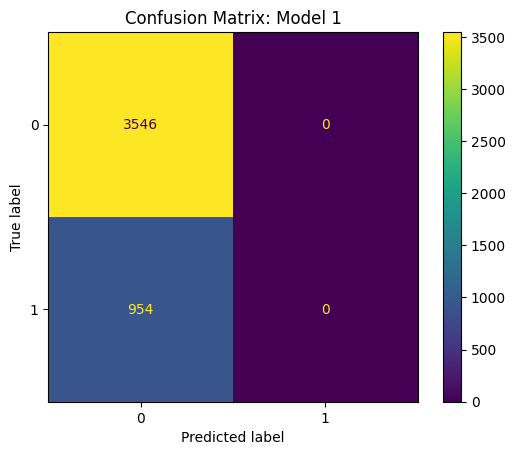

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay

# 1. Define features for this specific model
features_no_pay = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']

# 2. Update Preprocessor to ONLY include these features
# We reuse the transformers we defined earlier
preprocessor_1 = ColumnTransformer(
    transformers=[
        ('scale', scale_transformer, ['AGE', 'LIMIT_BAL']),
        ('cat', cat_transformer, ['SEX', 'EDUCATION', 'MARRIAGE'])
    ])

# 3. Create and Fit Pipeline
pipe_log_1 = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipe_log_1.fit(X_train, y_train)

# 4. Predictions for Validation Set
y_val_pred_1 = pipe_log_1.predict(X_val)

# 5. Reporting Metrics (Required by instructions)
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_1):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_1):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_1):.4f}")

# 6. Confusion Matrix
cm1 = confusion_matrix(y_val, y_val_pred_1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp1.plot()
plt.title("Confusion Matrix: Model 1")
plt.show()

In [44]:
# We create interactions for the three pairs
# Note: We use .astype(int) for Education to allow the math to work
for df_x in [X_train, X_val, X_test]:
    # 1. Interaction between two numeric variables
    df_x['LIMIT_AGE'] = df_x['LIMIT_BAL'] * df_x['AGE']
    
    # 2. Interaction between numeric and categorical (treated as numeric for the math)
    df_x['LIMIT_EDU'] = df_x['LIMIT_BAL'] * df_x['EDUCATION'].astype(int)
    df_x['AGE_EDU'] = df_x['AGE'] * df_x['EDUCATION'].astype(int)

# Update the list of features that need scaling to include these new, large numbers
scale_features_interaction = ['AGE', 'LIMIT_BAL', 'LIMIT_AGE', 'LIMIT_EDU', 'AGE_EDU']

### *B. Model 2*

--- Model 2: All Features ---
Accuracy:  0.8236
Precision: 0.7500
Recall:    0.2516


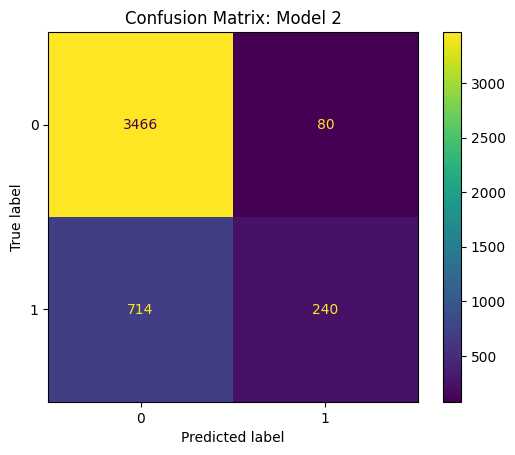

In [45]:
# 1. Define all features for Model 2
features_all = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3']

# 2. Build the Preprocessor for all features
# Note: We include 'num' for the PAY variables which don't need scaling but need imputation
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('scale', scale_transformer, ['AGE', 'LIMIT_BAL']),
        ('cat', cat_transformer, ['SEX', 'EDUCATION', 'MARRIAGE']),
        ('num', num_transformer, ['PAY_0', 'PAY_2', 'PAY_3'])
    ])

# 3. Create and Fit Pipeline
pipe_log_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipe_log_2.fit(X_train, y_train)

# 4. Evaluate on Validation Set
y_val_pred_2 = pipe_log_2.predict(X_val)

print("--- Model 2: All Features ---")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_2):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_2):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_2):.4f}")

# Confusion Matrix
cm2 = confusion_matrix(y_val, y_val_pred_2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot()
plt.title("Confusion Matrix: Model 2")
plt.show()

### *C. Model 3*

--- Model 3: All Features + Interactions ---
Accuracy:  0.8247
Precision: 0.7477
Recall:    0.2610


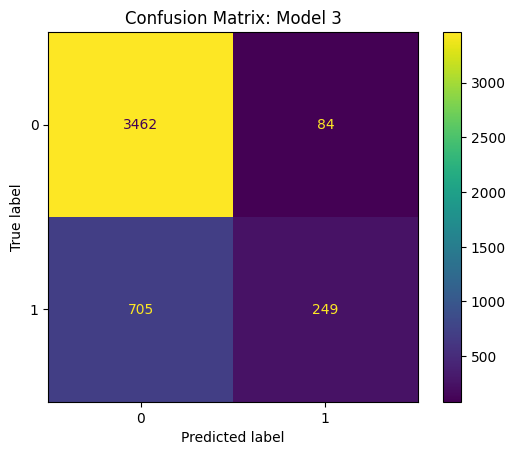

In [46]:
# 1. Build the Preprocessor for Model 3
preprocessor_3 = ColumnTransformer(
    transformers=[
        ('scale', scale_transformer, scale_features_interaction),
        ('cat', cat_transformer, ['SEX', 'EDUCATION', 'MARRIAGE']),
        ('num', num_transformer, ['PAY_0', 'PAY_2', 'PAY_3'])
    ])

# 2. Create and Fit Pipeline
pipe_log_3 = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipe_log_3.fit(X_train, y_train)

# 3. Evaluate on Validation Set
y_val_pred_3 = pipe_log_3.predict(X_val)

print("--- Model 3: All Features + Interactions ---")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_3):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_3):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_3):.4f}")

# Confusion Matrix
cm3 = confusion_matrix(y_val, y_val_pred_3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp3.plot()
plt.title("Confusion Matrix: Model 3")
plt.show()

## The Final Model Analysis

--- FINAL EVALUATION ON TEST SET (Model 3) ---
Accuracy:  0.8064
Precision: 0.7009
Recall:    0.2311


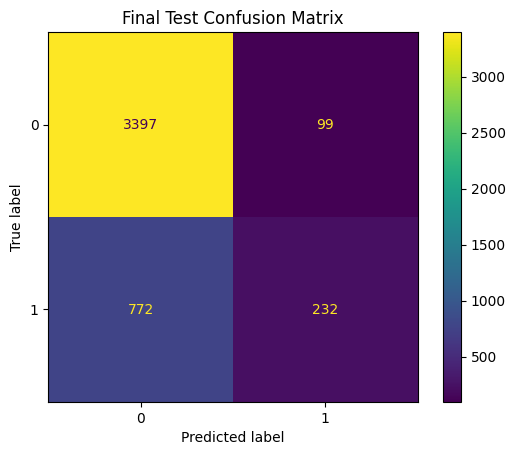

In [47]:
# Report the test data for the BEST model
y_test_pred = pipe_log_3.predict(X_test)

print("--- FINAL EVALUATION ON TEST SET (Model 3) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")

# Final Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot()
plt.title("Final Test Confusion Matrix")
plt.show()

### *Breakdown*

Question: What metric would you use to choose the best model in this context? Which model is the “best” and why? Explain if there are any risks of over/underfitting.
- *I would use [Recall] since the cost of a false negative (or a potential default) is very high and if so, the bank loses the entire loan amount which is worst-case-scenario. This is greater than the cost of manually reviewing a flagged account that might not default (false positive)*

- *In this case, Model 3 would win with a [Recall] of .2611 on the validation set and a .2311 on the test set which points to slight overfitting.*

- *Model 3 does risk overfitting (like I pointed out above) as we made the model more complex.*